In [59]:
import pandas as pd

file = "C:\\SNU EnSite\\2024_JSSP_GA\\result\\250316_BSFS_seed0.csv"
# file = "C:\\SNU EnSite\\2024_JSSP_GA\\result\\250307_BSFS.csv"
result = pd.read_csv(file)
result

,Problem,I_b,I_f,RUBI Ratio,Seed,Best Makespan,Best Reached Time
0,BS_1010_01,0.400000,0.432099,0,0,1125,318.379122
1,BS_1010_01,0.400000,0.432099,40,0,1073,383.167274
2,BS_1010_02,0.433333,0.419753,0,0,962,350.682488
3,BS_1010_02,0.433333,0.419753,40,0,842,385.064258
4,BS_1010_03,0.455556,0.444444,0,0,1093,347.822413
...,...,...,...,...,...,...,...
75,FS_1010_08,0.388889,0.654321,40,1,993,235.484822
76,FS_1010_09,0.411111,0.728395,0,1,1177,309.101205
77,FS_1010_09,0.411111,0.728395,40,1,1144,282.300477
78,FS_1010_10,0.422222,0.753086,0,1,953,389.887357


In [71]:

# 'Problem' 컬럼에서 unique한 값 추출
unique_problems = result['Problem'].unique()

# 'BS'로 시작하는 값 필터링
bs_problems = [p for p in unique_problems if p.startswith('BS')]
fs_problems = [p for p in unique_problems if p.startswith('FS')]


In [72]:
bs_problems

['BS_1010_01',
 'BS_1010_02',
 'BS_1010_03',
 'BS_1010_04',
 'BS_1010_05',
 'BS_1010_06',
 'BS_1010_07',
 'BS_1010_08',
 'BS_1010_09',
 'BS_1010_10']

In [73]:

def process_problem_group(df, problem_list):
    # 필터링
    filtered_df = df[df['Problem'].isin(problem_list)].copy()
    filtered_df['Problem'] = filtered_df['Problem'].str[-2:]  # 마지막 3자리 유지
    
    # 'Problem' 별로 그룹화
    grouped = filtered_df.groupby('Problem')

    processed_rows = []
    for name, group in grouped:
        if len(group) == 4:  # 두 개의 행이 있는 경우에만 처리
            row1, row2 = group.iloc[0], group.iloc[1]
            ratio1 = row2['Best Makespan'] / row1['Best Makespan']
            
            row3, row4 = group.iloc[2], group.iloc[3]
            print(row3['Best Makespan'], row4['Best Makespan'])
            ratio2 = row4['Best Makespan'] / row3['Best Makespan']
            processed_rows.append([name, row1['I_b'], row1['I_f'], (ratio1+ratio2)/2])
        if len(group) == 2:  # 두 개의 행이 있는 경우에만 처리
            row1, row2 = group.iloc[0], group.iloc[1]
            ratio1 = row2['Best Makespan'] / row1['Best Makespan']
            
            # row3, row4 = group.iloc[2], group.iloc[3]
            # ratio2 = row4['Best Makespan'] / row3['Best Makespan']
            processed_rows.append([name, row1['I_b'], row1['I_f'], ratio1])

    return pd.DataFrame(processed_rows, columns=['Problem', 'I_b', 'I_f', 'ratio'])

# BS 및 FS 데이터프레임 생성
bs_data = process_problem_group(result, bs_problems)
fs_data = process_problem_group(result, fs_problems)

# 결과 확인
print(bs_data.head())
print(fs_data.head())

1140 1061
972 903
1133 1063
1191 1158
1208 1208
1278 1250
1305 1331
1455 1307
1328 1524
1294 1228
1005 1012
1096 1098
927 922
1095 1059
1065 1029
1024 970
1037 998
947 993
1177 1144
953 939
  Problem       I_b       I_f     ratio
0      01  0.400000  0.432099  0.942240
1      02  0.433333  0.419753  0.902136
2      03  0.455556  0.444444  0.981917
3      04  0.488889  0.481481  0.972092
4      05  0.511111  0.333333  0.948770
  Problem       I_b       I_f     ratio
0      01  0.355556  0.407407  1.010525
1      02  0.400000  0.345679  0.987469
2      03  0.366667  0.395062  0.996250
3      04  0.422222  0.432099  0.984048
4      05  0.433333  0.493827  0.968033


In [63]:
bs_data

,Problem,I_b,I_f,ratio
0,01,0.400000,0.432099,0.942240
1,02,0.433333,0.419753,0.902136
2,03,0.455556,0.444444,0.981917
3,04,0.488889,0.481481,0.972092
4,05,0.511111,0.333333,0.948770
5,06,0.588889,0.506173,1.000254
6,07,0.744444,0.641975,0.998981
7,08,0.777778,0.666667,0.933351
8,09,0.922222,0.901235,1.072412
9,10,0.900000,0.851852,1.016023


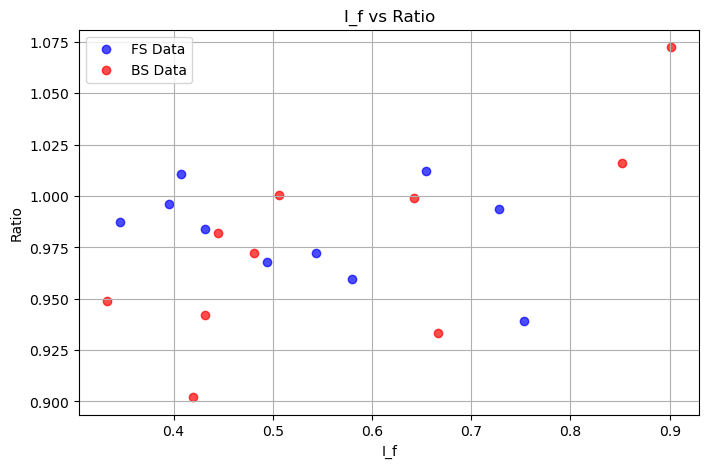

In [64]:
import matplotlib.pyplot as plt

# 그래프 그리기
plt.figure(figsize=(8, 5))
plt.scatter(fs_data['I_f'], fs_data['ratio'], color='b', alpha=0.7, label='FS Data')
plt.scatter(bs_data['I_f'], bs_data['ratio'], color='r', alpha=0.7, label='BS Data')

# 그래프 꾸미기
plt.xlabel('I_f')
plt.ylabel('Ratio')
plt.title('I_f vs Ratio')
plt.legend()
plt.grid(True)

# 그래프 표시
plt.show()


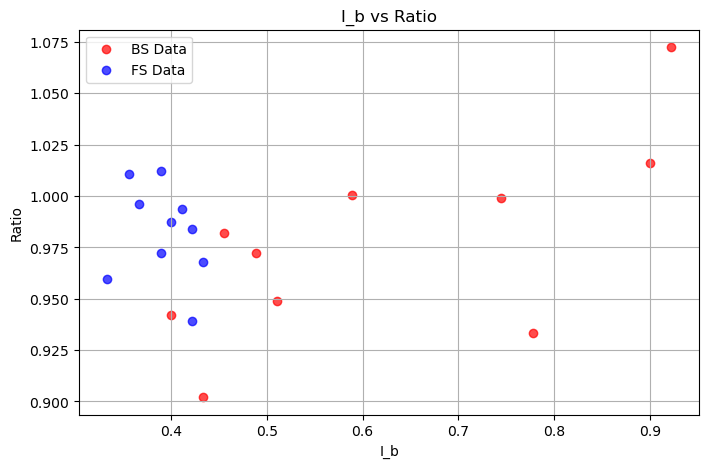

In [65]:

# 그래프 그리기
plt.figure(figsize=(8, 5))
plt.scatter(bs_data['I_b'], bs_data['ratio'], color='r', alpha=0.7, label='BS Data')
plt.scatter(fs_data['I_b'], fs_data['ratio'], color='b', alpha=0.7, label='FS Data')

# 그래프 꾸미기
plt.xlabel('I_b')
plt.ylabel('Ratio')
plt.title('I_b vs Ratio')
plt.legend()
plt.grid(True)

# 그래프 표시
plt.show()

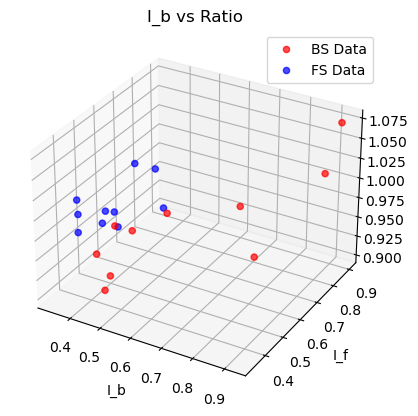

In [66]:
fig = plt.figure()
ax =  fig.add_subplot(111, projection='3d')

ax.scatter(bs_data['I_b'],bs_data['I_f'], bs_data['ratio'], color='r', alpha=0.7, label='BS Data')
ax.scatter(fs_data['I_b'],fs_data['I_f'], fs_data['ratio'], color='b', alpha=0.7, label='FS Data')

# 그래프 꾸미기
plt.xlabel('I_b')
plt.ylabel('I_f')
plt.title('I_b vs Ratio')
plt.legend()
plt.grid(True)

# 그래프 표시
plt.show()

In [67]:
# import seaborn as sns

# 상관계수 계산
correlation_matrix = fs_data[['I_b', 'I_f', 'ratio']].corr()
print(correlation_matrix)

            I_b       I_f     ratio
I_b    1.000000  0.218313 -0.254503
I_f    0.218313  1.000000 -0.369174
ratio -0.254503 -0.369174  1.000000


In [69]:
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 두 데이터프레임 합치기
combined_data = pd.concat([bs_data, fs_data], ignore_index=True)

# 독립 변수 (X)와 종속 변수 (y) 설정
X = combined_data[['I_b', 'I_f']]
y = combined_data['ratio']

# 상수항 추가 (y 절편 포함)
X = sm.add_constant(X)

# OLS(최소제곱법) 회귀 분석 실행
model = sm.OLS(y, X).fit()

# 결과 출력
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  ratio   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     2.214
Date:                Mon, 17 Mar 2025   Prob (F-statistic):              0.140
Time:                        16:16:41   Log-Likelihood:                 40.352
No. Observations:                  20   AIC:                            -74.70
Df Residuals:                      17   BIC:                            -71.72
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9223      0.029     32.297      0.0